In [44]:
# Working directory 설정 (주석이랑 같이 적으면 오류 남 -> cd 앞에 ! 붙여서 해결)

In [45]:
cd C:\Users\tr432\Downloads\WeeksMerged_16sSeq\Rarefaction

C:\Users\tr432\Downloads\WeeksMerged_16sSeq\Rarefaction


In [46]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import matplotlib.pylab as pylab
import numpy as np

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [47]:
df = pd.read_csv('pielou_rarefaction.csv', header=None)
df.columns = df.iloc[0]
df = df.reindex(df.index.drop(0)).reset_index(drop=True)

cols = list(df.columns)
new_names = []
for c in cols[1:100]:
    m = re.match(r"^depth-(\d+)_iter-\d+$", str(c))
    if m:
        new_names.append(m.group(1))   # depth 뒤 숫자만
    else:
        new_names.append(c)            # 패턴 안 맞으면 그대로

# 열이름 교체
df.columns = [cols[0]] + new_names + cols[100:]

# depth 열 이름 목록 (문자열) + 숫자형 depth 값 따로
depth_cols = new_names
val = df.columns[1:100].unique()

val

Index(['1', '14588', '29176', '43764', '58352', '72940', '87528', '102116',
       '116704', '131292'],
      dtype='object')

In [48]:
df_rev=pd.melt(df, id_vars="Group", value_vars=val)
df_rev["value"] = df_rev["value"].astype(float)

df_rev

,Group,variable,value
0,Control,1,NaN
1,Control,1,NaN
2,Control,1,NaN
3,Control,1,NaN
4,Control,1,NaN
...,...,...,...
4153,VNAM,131292,NaN
4154,VNAM,131292,NaN
4155,VNAM,131292,NaN
4156,VNAM,131292,NaN


In [49]:
df_rev2=df_rev.rename(columns={"Group":"Sample_Type", "variable":"Depth", "value":"diversity"})
df_rev2

,Sample_Type,Depth,diversity
0,Control,1,NaN
1,Control,1,NaN
2,Control,1,NaN
3,Control,1,NaN
4,Control,1,NaN
...,...,...,...
4153,VNAM,131292,NaN
4154,VNAM,131292,NaN
4155,VNAM,131292,NaN
4156,VNAM,131292,NaN


In [50]:
%matplotlib inline

In [51]:
custom = ["firebrick", "royalblue"]
sns.set_palette(sns.color_palette(custom))

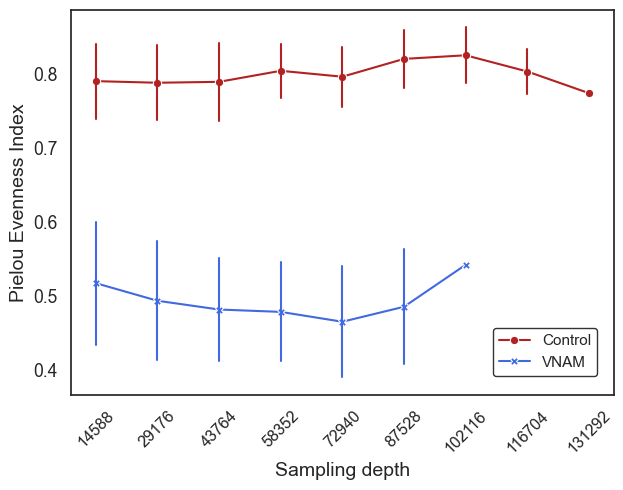

In [52]:
# Figure 스타일(테마) 지정 (whitegrid, darkgrid, white, dark, ticks 중 선택)
sns.set_style("white")

fig=plt.figure()
ax1=fig.add_subplot(1,1,1)

fig.set_size_inches(7,5)


sns.lineplot(data=df_rev2, x="Depth", y="diversity",
             hue="Sample_Type", err_style="bars", estimator="median", errorbar='sd',  ## estimator를 "mean"으로 뒀을때보다 "median"으로 두는게 qzv 결과랑 더 비슷함
             palette=custom, style="Sample_Type", dashes=False, markers=True,
             legend="full")

# ax1.set(ylim=(0, 130))

sns.set(font_scale=1.15)

plt.xlabel("Sampling depth",size=14)
plt.ylabel("Pielou Evenness Index", size=14)  #Edit

plt.xticks(fontsize=11.5, rotation=45)

plt.title("",size=15)


plt.legend(bbox_to_anchor=(0.97, 0.05),
           loc='lower right', borderaxespad=0, fontsize=11, 
           facecolor="white", edgecolor="black")

plt.savefig("rarefaction_pielou.png", bbox_inches='tight', dpi=500)
plt.show()